# Benchmark of Example 1: backends, time-domain route and original QuDPy

This notebook reports the cost of the open two-level calculation of `examples/example1_two_level_open.ipynb`. The measurements come from scripts in `validation/benchmarks/scripts/`, which write JSON files to `validation/results/data/`; this notebook reads those files, so opening it takes no time. In this notebook you will:

- compare the dense and the sparse backend (accuracy and time);
- compare the frequency-domain calculation with a time-sampled calculation followed by a Fourier transform;
- compare with the original QuDPy.

Timings were taken on one core of a laptop processor (BLAS limited to one thread), so they show scaling, not optimized performance. To measure again on your machine, set `rerun = True` in the next cell.

## 0. Imports and options

`run_script` launches one benchmark script with a single BLAS thread. It does nothing unless `rerun` is `True`. The comparison with the original QuDPy also needs a clone of `SilvaScience/QuDPy` (set `QUDPY_REPO` or place it next to this repository).

In [1]:
import json
import os
import subprocess
import sys
from pathlib import Path

sys.path.insert(0, "..")

import matplotlib.pyplot as plt
import numpy as np

from models import DATA, ANALYSIS_FIGURES, results_dirs

results_dirs()
SCRIPTS = Path("scripts")
rerun = False          # True: run the scripts below (about 20 minutes in total)


def run_script(name, *args):
    if not rerun:
        return
    env = dict(os.environ, OMP_NUM_THREADS="1", OPENBLAS_NUM_THREADS="1", MKL_NUM_THREADS="1")
    subprocess.run([sys.executable, str(SCRIPTS / name), *args], check=True, env=env)


def load(name):
    return json.loads((DATA / name).read_text())

## 1. Dense versus sparse backend

Script `bench_example1_dense_sparse.py` runs the example (polarization, action population and integrated fluorescence, $41\times41$ grid) with both backends. For two levels the Liouville matrix has 16 entries, so the dense backend wins: the sparse backend pays an iterative solve per frequency point.

In [2]:
run_script("bench_example1_dense_sparse.py")
ds = load("example1_dense_sparse.json")

print(f"grid {ds['grid']}, t2 = {ds['t2']}, eta = {ds['eta']}")
print(f"time: dense {ds['time_dense_s']:.2f} s, sparse {ds['time_sparse_s']:.2f} s")
print(f"{'observable/pathway':<22}max|dense - sparse| / max|dense|")
for key, value in ds["relative_difference"].items():
    print(f"{key:<22}{value:.1e}")
assert ds["worst"] < 1e-12

grid [41, 41], t2 = 10.0, eta = 0.002
time: dense 0.32 s, sparse 4.21 s
observable/pathway    max|dense - sparse| / max|dense|
polarization/R1       2.8e-15
polarization/R2       2.9e-15
population/R1         2.8e-15
population/R2         2.9e-15
fluorescence/R1       2.7e-15
fluorescence/R2       2.8e-15


The two backends agree to machine precision on every observable and pathway.

## 2. Frequency domain versus time sampling

The same spectrum can be obtained by sampling the response in time ($t_1$ and $t_3$ on a grid of step $dt$ up to a length $T$) and transforming it. Script `bench_time_fft.py` finds, for three damping regimes, the cheapest $(dt, T)$ that reaches a relative error of $10^{-2}$, $10^{-3}$ and $10^{-4}$ with respect to the frequency-domain result.

regime         width (eV)   target  N per axis  time (s)  frequency (s)
example1            0.052     0.01         167     0.004          0.232
example1            0.052    0.001         444     0.015          0.232
example1            0.052   0.0001         997     0.061          0.232
weak_damping        0.007     0.01        1235     0.083          0.219
weak_damping        0.007    0.001        1646     0.124          0.219
weak_damping        0.007   0.0001        3702     0.553          0.219
closed              0.002     0.01        4318     0.741          0.200
closed              0.002    0.001        5757     1.302          0.200
closed              0.002   0.0001        6477     1.609          0.200


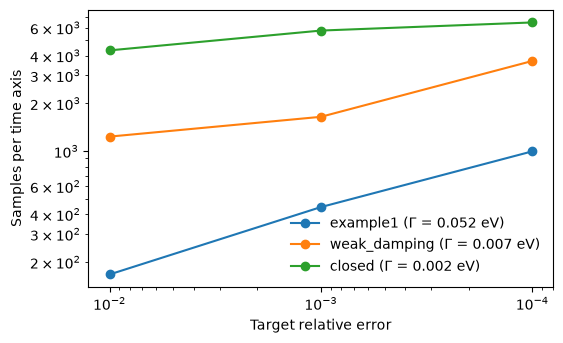

In [3]:
run_script("bench_time_fft.py")
tf = load("time_fft.json")

print(f"{'regime':<14}{'width (eV)':>11}{'target':>9}{'N per axis':>12}{'time (s)':>10}{'frequency (s)':>15}")
for regime, report in tf.items():
    for target, best in report["best"].items():
        print(f"{regime:<14}{report['coherence_width']:>11.3f}{target:>9}{best['N_per_axis']:>12}"
              f"{best['time_s']:>10.3f}{report['reference_time_s']:>15.3f}")

fig, ax = plt.subplots(figsize=(6.0, 3.6))
for regime, report in tf.items():
    widths = report["coherence_width"]
    targets = list(report["best"])
    ax.loglog([float(t) for t in targets], [report["best"][t]["N_per_axis"] for t in targets], "o-", label=f"{regime} ($\\Gamma$ = {widths:.3f} eV)")
ax.set_xlabel("Target relative error")
ax.set_ylabel("Samples per time axis")
ax.invert_xaxis()
ax.legend(frameon=False)
fig.savefig(ANALYSIS_FIGURES / "example1_benchmark_time_route.pdf", bbox_inches="tight")
plt.show()

The number of samples grows as the damping weakens (the response lasts longer) and as the target tightens. For this two-level system with strong damping the time route is faster (a few ms against 0.2 s); it becomes slower than the frequency-domain evaluation, which costs the same for all regimes since it works with the poles directly, once the damping is weak (about 1 s for the closed system).

## 3. Original QuDPy

Script `bench_qudpy_series.py` runs `System.coherence2d` of the original QuDPy (QuTiP `mesolve`) on the same model and grid, for the $(dt,T)$ that reach each target, and compares the time with QuDPy-FDGF. The rows `tight` repeat the last two cases with tighter `mesolve` tolerances.

In [4]:
run_script("bench_qudpy_series.py")
qd = load("qudpy_original.json")

print(f"{'case':<10}{'tight':<7}{'dt':>6}{'T':>6}{'N':>6}{'error':>9}{'QuDPy (s)':>11}{'FDGF (s)':>10}{'ratio':>7}{'peak MB':>9}")
for row in qd:
    print(f"{row['case']:<10}{str(row.get('tight', False)):<7}{row['dt']:>6.2f}{row['T']:>6.0f}{row['N_per_axis']:>6}"
          f"{row['error']:>9.1e}{row['time_qudpy_s']:>11.2f}{row['time_fdgf_s']:>10.3f}"
          f"{row['time_qudpy_s'] / row['time_fdgf_s']:>7.0f}{row['peak_MB_qudpy']:>9.0f}")

ratios = [r["time_qudpy_s"] / r["time_fdgf_s"] for r in qd]
print(f"QuDPy-FDGF is {min(ratios):.0f} to {max(ratios):.0f} times faster on these cases")

case      tight      dt     T     N    error  QuDPy (s)  FDGF (s)  ratio  peak MB
example1  False    0.81   133   166  2.2e-03       1.45     0.173      8       10
example1  False    0.40   177   442  6.2e-04       5.67     0.169     34       66
example1  False    0.20   199   995  5.3e-04      20.40     0.163    125      333
weak      False    0.80   987  1233  7.4e-03      68.23     0.168    406      506
weak      False    0.80  1316  1645  5.7e-03      96.32     0.160    602      900
example1  True     0.20   199   995  9.1e-05      21.98     0.149    148      332
weak      True     0.80  1316  1645  2.4e-04     124.90     0.152    822      900
QuDPy-FDGF is 8 to 822 times faster on these cases


With the default tolerances of `mesolve`, the finest cases stay at an error of $5\times10^{-4}$ (Example 1) and $6\times10^{-3}$ (weak damping) instead of the targeted $10^{-4}$ and $10^{-3}$: the error is dominated by the integrator, not by the sampling. The `tight` rows reach $9\times10^{-5}$ and $2\times10^{-4}$, at the same cost. Memory grows as $N^2$ since all propagated states are kept.

## Summary

- For two levels the dense backend is the right choice; the sparse backend agrees to machine precision.
- A time-sampled route needs from hundreds to thousands of samples per axis as the damping weakens, while the frequency-domain cost does not depend on it.
- The original QuDPy takes from seconds to minutes for a map that QuDPy-FDGF evaluates in about 0.2 s.